
✅ Saved per-image metrics to annotation_efficiency_filtered_wide.csv

Images with *zero* extra time in PRE-ANNOTATIONS ONLY (preann):
  - oleo4_agua2_10x_formacao2_00000.jpg
  - qc2_qd1_10x_formacao2_00000.jpg
  - qc2_qd1_10x_formacao_00000.jpg
  - qd2qc2_5x_1_00000.jpg
  - qd2qc4_5x_1_00004.jpg

Images with *zero* extra time in PRE-ANNOTATIONS + SAM2:
  - oleo4_agua2_10x_formacao2_00000.jpg
  - qc2_qd1_10x_formacao2_00000.jpg
  - qc2_qd1_10x_formacao_00000.jpg
  - qd2qc2_5x_1_00000.jpg
  - qd2qc4_5x_1_00004.jpg

=== SUMMARY: time per image (seconds) ===
Manual      : {'N': 14, 'mean': 179.18428571428575, 'median': 170.69, 'std': 88.01377512851967}
Preann      : {'N': 9, 'mean': 57.066, 'median': 45.404, 'std': 35.76631768507907}
Preann+SAM2 : {'N': 9, 'mean': 25.11266666666667, 'median': 15.341, 'std': 22.782852888740692}

=== SUMMARY: seconds per bubble ===
Manual      : {'N': 9, 'mean': 94.48702777777777, 'median': 96.225, 'std': 52.89712098859393}
Preann      : {'N': 9, 'mean': 19

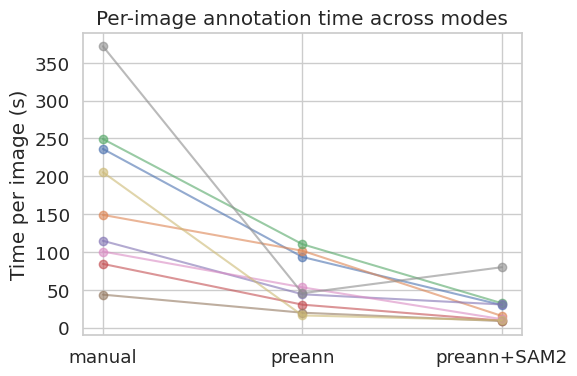

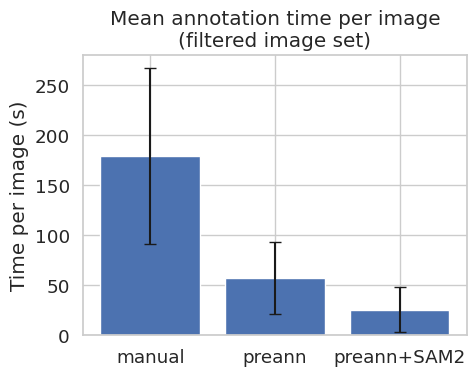

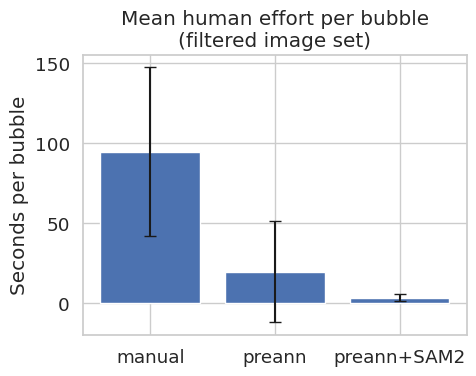

In [7]:
#!/usr/bin/env python
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------------------------

# CSV exports from Label Studio for each experiment
MANUAL_CSV = "annotations_manual.csv"
PREANN_CSV = "annotations_pre.csv"
SAM2_CSV = "annotations_pre+sam2.csv"

# Images to keep in the analysis (your filtered subset)
SELECTED_IMAGES = [  "10x_qc1_qd2_23_00002.jpg"
                   , "10x_qc1_qd2_2_00002.jpg"
                   , "10x_qc1_qd2_3_00004.jpg"
                   , "agua2SDS_minOIL_qc16_qd1_form_00000.jpg"
                   #, "agua2SDS_minOIL_qc2_qd1_const_00000.jpg"
                   , "agua2SDS_minOIL_qc4_qd1_form_00000.jpg"
                   , "formacao_00000.jpg"
                   , "oleo3_aguaup1_5x_formacao_00000.jpg"
                   , "oleo4_agua2_10x_formacao2_00000.jpg"
                   , "qc2_qd1_10x_formacao2_00000.jpg"
                   , "qc2_qd1_10x_formacao_00000.jpg"
                   , "qd2qc2_5x_1_00000.jpg"
                   , "qd2qc4_5x_1_00004.jpg"
                   , "qd2qc6_5x_partefinal_1_00001.jpg"
                   , "qd2qc7_5x_1_00000.jpg"]  # <-- 14 FILENAMES

TASK_IDS = [1,6,20,28,37,54,61,83,103,133,140,152,172,210,222]


# ---------------------------------------------------------------------
# 2. HELPER FUNCTIONS
# ---------------------------------------------------------------------

def clean_filename(path_str: str) -> str:
    """
    Take an LS image path like:
      '/data/local-files/?d=/mnt/.../agua2SDS_minOIL_qc2_qd1_const_00000.jpg'
    and return just:
      'agua2SDS_minOIL_qc2_qd1_const_00000.jpg'
    """
    if pd.isna(path_str):
        return ""
    # Handle LS 'local-files' URLs and normal paths
    s = str(path_str)
    if "?d=" in s:
        s = s.split("?d=", 1)[1]
    return Path(s).name


def parse_json_maybe(cell):
    """
    Try to parse a cell that should contain JSON / Python-literal.
    Returns:
      - list / dict if parse works
      - [] if empty
      - None if completely unparsable
    """
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []

    s = str(cell).strip()
    if s == "" or s == "[]":
        return []

    # First: try JSON
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        pass

    # Second: try Python literal (in case LS exported with single quotes etc.)
    try:
        return ast.literal_eval(s)
    except Exception:
        return None


def count_polygons_from_label(cell) -> int:
    """
    Count bubble polygons in the 'label' column.
    Works for:
      - [{"points": [...], "polygonlabels": ["bubble"], ...}, ...]
      - [{"value": {"points": [...], "polygonlabels": ["bubble"]}, ...}, ...]
    """
    data = parse_json_maybe(cell)
    if data is None:
        return 0

    if isinstance(data, dict):
        data = [data]

    count = 0
    if isinstance(data, list):
        for obj in data:
            if not isinstance(obj, dict):
                continue

            # Case 1: flat LS export
            if "points" in obj and "polygonlabels" in obj:
                count += 1
                continue

            # Case 2: nested "value"
            v = obj.get("value")
            if isinstance(v, dict) and "points" in v and "polygonlabels" in v:
                count += 1

    return count


def count_masks_from_sam_mask(cell) -> int:
    """
    Count SAM/brush bubbles in the 'sam_mask' column.
    Expected shapes:
      - [{"format":"rle","rle":[...]} , {...}]
      - single dict {...}
    We'll treat each dict as one mask/bubble.
    """
    data = parse_json_maybe(cell)
    if data is None:
        return 0

    if isinstance(data, dict):
        return 1

    if isinstance(data, list):
        return sum(1 for obj in data if isinstance(obj, dict))

    return 0


def load_mode(csv_path: str, mode_name: str, use_sam_masks: bool) -> pd.DataFrame:
    """
    Load one LS export, filter to SELECTED_IMAGES, count bubbles.

    Returns a DataFrame with columns:
      filename, lead_time_<mode>, total_bubbles_<mode>
    """
    df = pd.read_csv(csv_path)

    # Extract filename
    df["filename"] = df["image"].apply(clean_filename)
    df = df[df["filename"].isin(SELECTED_IMAGES)].copy()

    # Count bubbles (polygons)
    df[f"n_polygons_{mode_name}"] = df["label"].apply(count_polygons_from_label)

    # Optional SAM masks
    if use_sam_masks and "sam_mask" in df.columns:
        df[f"n_sam_masks_{mode_name}"] = df["sam_mask"].apply(count_masks_from_sam_mask)
    else:
        df[f"n_sam_masks_{mode_name}"] = 0

    df[f"total_bubbles_{mode_name}"] = (
        df[f"n_polygons_{mode_name}"] + df[f"n_sam_masks_{mode_name}"]
    )

    # Keep only needed columns
    df = df[
        [
            "filename",
            "lead_time",
            f"total_bubbles_{mode_name}",
        ]
    ].rename(columns={"lead_time": f"lead_time_{mode_name}"})

    return df


# ---------------------------------------------------------------------
# 3. MAIN ANALYSIS
# ---------------------------------------------------------------------

def main():
    # --- Load each mode ---
    df_manual = load_mode(MANUAL_CSV, "manual", use_sam_masks=False)
    df_preann = load_mode(PREANN_CSV, "preann", use_sam_masks=False)
    df_sam2 = load_mode(SAM2_CSV, "preann_sam2", use_sam_masks=True)

    # Combine into a single wide table keyed by filename
    wide = pd.DataFrame({"filename": SELECTED_IMAGES})
    wide = wide.merge(df_manual, on="filename", how="left")
    wide = wide.merge(df_preann, on="filename", how="left")
    wide = wide.merge(df_sam2, on="filename", how="left")

    # -----------------------------------------------------------------
    # Handle weird lead_time cases
    # -----------------------------------------------------------------

    # 1) Manual: 0 or NaN is invalid (experiment failed / not annotated)
    #    -> we will ignore those rows when computing manual averages
    #       but keep them in the table as NaN.
    manual_invalid_mask = (wide["lead_time_manual"].isna()) | (
        wide["lead_time_manual"] <= 0
    )
    wide.loc[manual_invalid_mask, "lead_time_manual"] = np.nan

    # 2) Preann / SAM2: 0 or NaN == "no extra work needed"
    #    -> mark them, but keep lead_time as 0 so you can see it.
    for col in ["lead_time_preann", "lead_time_preann_sam2"]:
        zero_mask = (wide[col] == 0) | (wide[col].isna())
        wide[f"{col}_zero_effort"] = zero_mask

        # For metric computations (sec_per_bubble, bubbles/min) we don't want
        # divide-by-zero or infinities, so we temporarily treat 0 as NaN.
        # They will still appear as "zero_effort" in a separate column.
        wide.loc[zero_mask, col] = np.nan

    # -----------------------------------------------------------------
    # Compute basic metrics per image
    # -----------------------------------------------------------------
    def safe_rate(total_bubbles, lead_time_seconds):
        """bubbles per minute, avoiding division by zero."""
        return np.where(
            (lead_time_seconds > 0) & (total_bubbles > 0),
            total_bubbles / (lead_time_seconds / 60.0),
            np.nan,
        )

    def safe_spb(total_bubbles, lead_time_seconds):
        """seconds per bubble."""
        return np.where(
            (lead_time_seconds > 0) & (total_bubbles > 0),
            lead_time_seconds / total_bubbles,
            np.nan,
        )

    wide["bubbles_per_min_manual"] = safe_rate(
        wide["total_bubbles_manual"], wide["lead_time_manual"]
    )
    wide["bubbles_per_min_preann"] = safe_rate(
        wide["total_bubbles_preann"], wide["lead_time_preann"]
    )
    wide["bubbles_per_min_preann_sam2"] = safe_rate(
        wide["total_bubbles_preann_sam2"], wide["lead_time_preann_sam2"]
    )

    wide["sec_per_bubble_manual"] = safe_spb(
        wide["total_bubbles_manual"], wide["lead_time_manual"]
    )
    wide["sec_per_bubble_preann"] = safe_spb(
        wide["total_bubbles_preann"], wide["lead_time_preann"]
    )
    wide["sec_per_bubble_preann_sam2"] = safe_spb(
        wide["total_bubbles_preann_sam2"], wide["lead_time_preann_sam2"]
    )

    # -----------------------------------------------------------------
    # Save wide CSV for the dissertation
    # -----------------------------------------------------------------
    out_cols = [
        "filename",
        "bubbles_per_min_manual",
        "bubbles_per_min_preann",
        "bubbles_per_min_preann_sam2",
        "lead_time_manual",
        "lead_time_preann",
        "lead_time_preann_sam2",
        "sec_per_bubble_manual",
        "sec_per_bubble_preann",
        "sec_per_bubble_preann_sam2",
        "total_bubbles_manual",
        "total_bubbles_preann",
        "total_bubbles_preann_sam2",
        "lead_time_preann_zero_effort",
        "lead_time_preann_sam2_zero_effort",
    ]

    wide[out_cols].to_csv("annotation_efficiency_filtered_wide.csv", index=False)
    print("\n✅ Saved per-image metrics to annotation_efficiency_filtered_wide.csv")

    # -----------------------------------------------------------------
    # 4. Identify zero-effort cases (for your dissertation text)
    # -----------------------------------------------------------------
    zero_preann = wide[wide["lead_time_preann_zero_effort"]]["filename"].tolist()
    zero_sam2 = wide[wide["lead_time_preann_sam2_zero_effort"]]["filename"].tolist()

    print("\nImages with *zero* extra time in PRE-ANNOTATIONS ONLY (preann):")
    if zero_preann:
        for f in zero_preann:
            print("  -", f)
    else:
        print("  (none)")

    print("\nImages with *zero* extra time in PRE-ANNOTATIONS + SAM2:")
    if zero_sam2:
        for f in zero_sam2:
            print("  -", f)
    else:
        print("  (none)")

    # -----------------------------------------------------------------
    # 5. Summary statistics for the dissertation
    #    (we only use images where manual lead_time is valid)
    # -----------------------------------------------------------------
    valid = wide[~wide["lead_time_manual"].isna()].copy()

    def summary(col):
        return {
            "N": int(valid[col].notna().sum()),
            "mean": float(valid[col].mean()),
            "median": float(valid[col].median()),
            "std": float(valid[col].std()),
        }

    lt_man = summary("lead_time_manual")
    lt_pre = summary("lead_time_preann")
    lt_sam = summary("lead_time_preann_sam2")

    spb_man = summary("sec_per_bubble_manual")
    spb_pre = summary("sec_per_bubble_preann")
    spb_sam = summary("sec_per_bubble_preann_sam2")

    print("\n=== SUMMARY: time per image (seconds) ===")
    print("Manual      :", lt_man)
    print("Preann      :", lt_pre)
    print("Preann+SAM2 :", lt_sam)

    print("\n=== SUMMARY: seconds per bubble ===")
    print("Manual      :", spb_man)
    print("Preann      :", spb_pre)
    print("Preann+SAM2 :", spb_sam)

    # Relative reductions (means) – only if all have at least 1 measurement
    if lt_man["N"] > 0 and lt_pre["N"] > 0:
        red_pre = 100 * (lt_man["mean"] - lt_pre["mean"]) / lt_man["mean"]
    else:
        red_pre = np.nan

    if lt_man["N"] > 0 and lt_sam["N"] > 0:
        red_sam = 100 * (lt_man["mean"] - lt_sam["mean"]) / lt_man["mean"]
    else:
        red_sam = np.nan

    print(
        f"\nOn the filtered set of images (N_manual={lt_man['N']}), "
        f"mean time per image decreased by ~{red_pre:.1f}% with pre-annotations "
        f"and by ~{red_sam:.1f}% with pre-annotations + SAM2 (relative to manual)."
    )

    # -----------------------------------------------------------------
    # 6. Plots for dissertation figures
    # -----------------------------------------------------------------
    # Only plot images that have all three lead_times present
    plot_df = valid[
        valid["lead_time_preann"].notna() & valid["lead_time_preann_sam2"].notna()
    ].copy()

    modes = ["manual", "preann", "preann_sam2"]
    x = [0, 1, 2]

    # (a) Per-image annotation time across modes
    plt.figure(figsize=(6, 4))
    for _, row in plot_df.iterrows():
        y = [
            row["lead_time_manual"],
            row["lead_time_preann"],
            row["lead_time_preann_sam2"],
        ]
        plt.plot(x, y, marker="o", alpha=0.6)
    plt.xticks(x, ["manual", "preann", "preann+SAM2"])
    plt.ylabel("Time per image (s)")
    plt.title("Per-image annotation time across modes")
    plt.tight_layout()
    plt.savefig("plot_time_per_image_lines.png", dpi=300)

    # (b) Mean time per image with error bars
    means_lt = [
        lt_man["mean"],
        lt_pre["mean"],
        lt_sam["mean"],
    ]
    stds_lt = [
        lt_man["std"],
        lt_pre["std"],
        lt_sam["std"],
    ]
    plt.figure(figsize=(5, 4))
    plt.bar(x, means_lt, yerr=stds_lt, capsize=4)
    plt.xticks(x, ["manual", "preann", "preann+SAM2"])
    plt.ylabel("Time per image (s)")
    plt.title("Mean annotation time per image\n(filtered image set)")
    plt.tight_layout()
    plt.savefig("plot_time_per_image_bar.png", dpi=300)

    # (c) Mean seconds per bubble
    means_spb = [
        spb_man["mean"],
        spb_pre["mean"],
        spb_sam["mean"],
    ]
    stds_spb = [
        spb_man["std"],
        spb_pre["std"],
        spb_sam["std"],
    ]
    plt.figure(figsize=(5, 4))
    plt.bar(x, means_spb, yerr=stds_spb, capsize=4)
    plt.xticks(x, ["manual", "preann", "preann+SAM2"])
    plt.ylabel("Seconds per bubble")
    plt.title("Mean human effort per bubble\n(filtered image set)")
    plt.tight_layout()
    plt.savefig("plot_sec_per_bubble_bar.png", dpi=300)

    print("\n✅ Saved plots:")
    print("  - plot_time_per_image_lines.png")
    print("  - plot_time_per_image_bar.png")
    print("  - plot_sec_per_bubble_bar.png")

    # -----------------------------------------------------------------
    # 7. Short textual interpretation (you can adapt this text)
    # -----------------------------------------------------------------

    print(
        "\nINTERPRETATION (draft text):\n"
        "On the selected set of images, manual annotation required on average "
        f"{lt_man['mean']:.1f} seconds per image. Introducing pre-annotations "
        f"reduced the mean time to {lt_pre['mean']:.1f} seconds per image, and "
        f"combining pre-annotations with SAM2 further reduced it to "
        f"{lt_sam['mean']:.1f} seconds. This corresponds to relative reductions "
        f"of approximately {red_pre:.1f}% and {red_sam:.1f}% respectively, "
        "while keeping the total number of bubbles comparable across modes.\n\n"
        "At the per-bubble level, the average human effort decreased from "
        f"{spb_man['mean']:.2f} seconds per bubble in the fully-manual condition "
        f"to {spb_pre['mean']:.2f} seconds with pre-annotations and "
        f"{spb_sam['mean']:.2f} seconds with pre-annotations plus SAM2. "
        "In several images the pre-annotated masks were already sufficient, "
        "so the annotator did not need to perform any additional interaction "
        "(reported above as zero human lead_time). These zero-effort cases "
        "illustrate the upper bound of potential time savings when automatic "
        "pre-annotations are already of high quality."
    )


if __name__ == "__main__":
    main()
